# EDA Perleberg — centrale solaire virtuelle

Je me concentre ici sur Perleberg, la centrale solaire virtuelle de 22,1 MW de mon portefeuille allemand. L'analyse porte sur la météo ERA5 et la production virtuelle au pas de 15 minutes.

## Charger les données du site

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / 'src').is_dir() and (candidate / 'config' / 'assets.yaml').is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError('Impossible de trouver la racine du projet Qair.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_assets

SITE = 'perleberg'
cfg = load_assets(PROJECT_ROOT / 'config' / 'assets.yaml')[SITE]
historical_path = PROJECT_ROOT / 'data' / 'asset_data' / f'{SITE}_historical_reanalysis_15m.parquet'
historical_data = pd.read_parquet(historical_path)
historical_data['timestamp'] = pd.to_datetime(historical_data['timestamp'], utc=True)
historical_data = historical_data.sort_values('timestamp').reset_index(drop=True)

MARKET_TZ = cfg['market_timezone']
CAPACITY_MW = float(cfg['capacity_mw'])
print(f'Site : {SITE}')
print(f'Fichier : {historical_path.name}')
print(f'Fuseau local : {MARKET_TZ}')
print(f'Capacité virtuelle : {CAPACITY_MW:.1f} MW')

Site : perleberg
Fichier : perleberg_historical_reanalysis_15m.parquet
Fuseau local : Europe/Berlin
Capacité virtuelle : 22.1 MW


## Vérifier les données historiques

Je vérifie la période couverte, la fréquence à 15 minutes et l'absence de valeurs manquantes avant de travailler sur la production.

In [3]:
timestamps = historical_data['timestamp']
quality = pd.DataFrame([{
    'rows': len(historical_data),
    'start_utc': timestamps.min(),
    'end_utc': timestamps.max(),
    'duplicates': int(timestamps.duplicated().sum()),
    'irregular_15m': int(timestamps.diff().dropna().ne(pd.Timedelta(minutes=15)).sum()),
    'missing_values': int(historical_data.isna().sum().sum()),
}])
quality

,rows,start_utc,end_utc,duplicates,irregular_15m,missing_values
0,93600,2024-01-01 00:00:00+00:00,2026-09-01 23:45:00+00:00,0,0,0


La grille couvre 93 600 quarts d'heure entre le 1er janvier 2024 et le 1er septembre 2026 en UTC. Les deux journées locales incomplètes sont simplement les bornes du fichier : le début est tronqué par le passage à l'heure de Berlin et la fin déborde sur le 2 septembre local. Elles sont exclues des statistiques journalières. Les journées de changement d'heure restent bien présentes avec 92 ou 100 périodes.

In [4]:
local_data = historical_data.assign(timestamp_local=historical_data['timestamp'].dt.tz_convert(MARKET_TZ))
local_data['local_date'] = local_data['timestamp_local'].dt.date
periods_by_day = local_data.groupby('local_date').size().rename('actual_periods')
day_audit = periods_by_day.to_frame()
day_audit['expected_periods'] = [
    len(pd.date_range(
        pd.Timestamp(day).tz_localize(MARKET_TZ),
        (pd.Timestamp(day) + pd.Timedelta(days=1)).tz_localize(MARKET_TZ),
        freq='15min', inclusive='left',
    ))
    for day in day_audit.index
]
day_audit['complete_day'] = day_audit['actual_periods'].eq(day_audit['expected_periods'])
complete_days = day_audit[day_audit['complete_day']]
partial_days = day_audit[~day_audit['complete_day']]
display(complete_days['actual_periods'].value_counts().sort_index().rename('complete_days'))
display(partial_days)

actual_periods
92       3
96     969
100      2
Name: complete_days, dtype: int64

,actual_periods,expected_periods,complete_day
local_date,,,
2024-01-01,92,96,False
2026-09-02,8,96,False


## Décrire la production et calculer l'énergie

Pour passer d'une puissance à une énergie sur un quart d'heure, je multiplie la puissance en MW par 0,25 heure.

In [5]:
solar_position = pvlib.solarposition.get_solarposition(
    pd.DatetimeIndex(historical_data['timestamp']), cfg['latitude'], cfg['longitude']
)
daylight = solar_position['apparent_elevation'].to_numpy() > 0
production = historical_data['production_mw']
radiation_columns = [
    'shortwave_radiation', 'direct_radiation',
    'diffuse_radiation', 'direct_normal_irradiance',
]
production_summary = pd.DataFrame([{
    'capacity_mw': CAPACITY_MW,
    'mean_production_mw': production.mean(),
    'p95_production_mw': production.quantile(0.95),
    'max_production_mw': production.max(),
    'mean_capacity_factor': historical_data['capacity_factor'].mean(),
    'zero_production_share': production.eq(0).mean(),
    'positive_at_night_rows': int(((~daylight) & production.gt(1e-9)).sum()),
    'production_outside_bounds': int((~production.between(0, CAPACITY_MW)).sum()),
    'negative_radiation_rows': int((historical_data[radiation_columns] < 0).any(axis=1).sum()),
}])
production_summary.T.rename(columns={0: 'value'})

,value
capacity_mw,22.100000
mean_production_mw,2.897361
p95_production_mw,13.267320
max_production_mw,18.244249
mean_capacity_factor,0.131102
zero_production_share,0.481218
positive_at_night_rows,0.000000
production_outside_bounds,0.000000
negative_radiation_rows,0.000000


In [6]:
INTERVAL_HOURS = 15 / 60
local_data['interval_energy_mwh'] = local_data['production_mw'] * INTERVAL_HOURS
daily = local_data.groupby('local_date').agg(
    periods=('timestamp', 'size'),
    energy_mwh=('interval_energy_mwh', 'sum'),
    max_power_mw=('production_mw', 'max'),
    mean_shortwave_wm2=('shortwave_radiation', 'mean'),
    mean_cloud_cover_pct=('cloud_cover', 'mean'),
)
daily = daily.loc[complete_days.index].copy()
daily.index = pd.to_datetime(daily.index)
daily[['energy_mwh', 'max_power_mw']].describe().T

,count,mean,std,min,25%,50%,75%,max
energy_mwh,974.0,69.597354,42.039100,1.813202,30.654572,72.498713,104.798662,150.118048
max_power_mw,974.0,10.472839,5.097709,0.362443,6.341974,11.360951,14.898116,18.244249


La production moyenne est de 2,90 MW, soit un facteur de charge moyen de 13,1 %. Elle est nulle sur 48,1 % des quarts d'heure et atteint 18,24 MW au maximum, sous la capacité virtuelle de 22,1 MW. Ce plafond plus bas n'est pas une erreur de fichier : il vient du modèle physique et des paramètres techniques retenus pour ce site virtuel. L'énergie quotidienne moyenne est de 69,6 MWh.

In [7]:
monthly = daily.assign(month=daily.index.month).groupby('month').agg(
    mean_daily_energy_mwh=('energy_mwh', 'mean'),
    p10_daily_energy_mwh=('energy_mwh', lambda values: values.quantile(0.10)),
    p90_daily_energy_mwh=('energy_mwh', lambda values: values.quantile(0.90)),
    mean_daily_peak_mw=('max_power_mw', 'mean'),
)
monthly

,mean_daily_energy_mwh,p10_daily_energy_mwh,p90_daily_energy_mwh,mean_daily_peak_mw
month,,,,
1,23.510534,5.505519,48.649613,5.198981
2,35.574798,7.787493,70.444735,6.744344
3,76.661580,38.456221,110.580082,12.331838
4,96.119061,43.965483,134.149653,13.714567
5,104.869512,69.989296,140.802699,14.096726
6,105.706287,69.169971,141.997772,13.943263
7,94.161141,49.690801,130.426781,12.753970
8,95.833778,57.446190,128.803682,13.298347
9,80.478309,47.240439,108.580470,12.291198


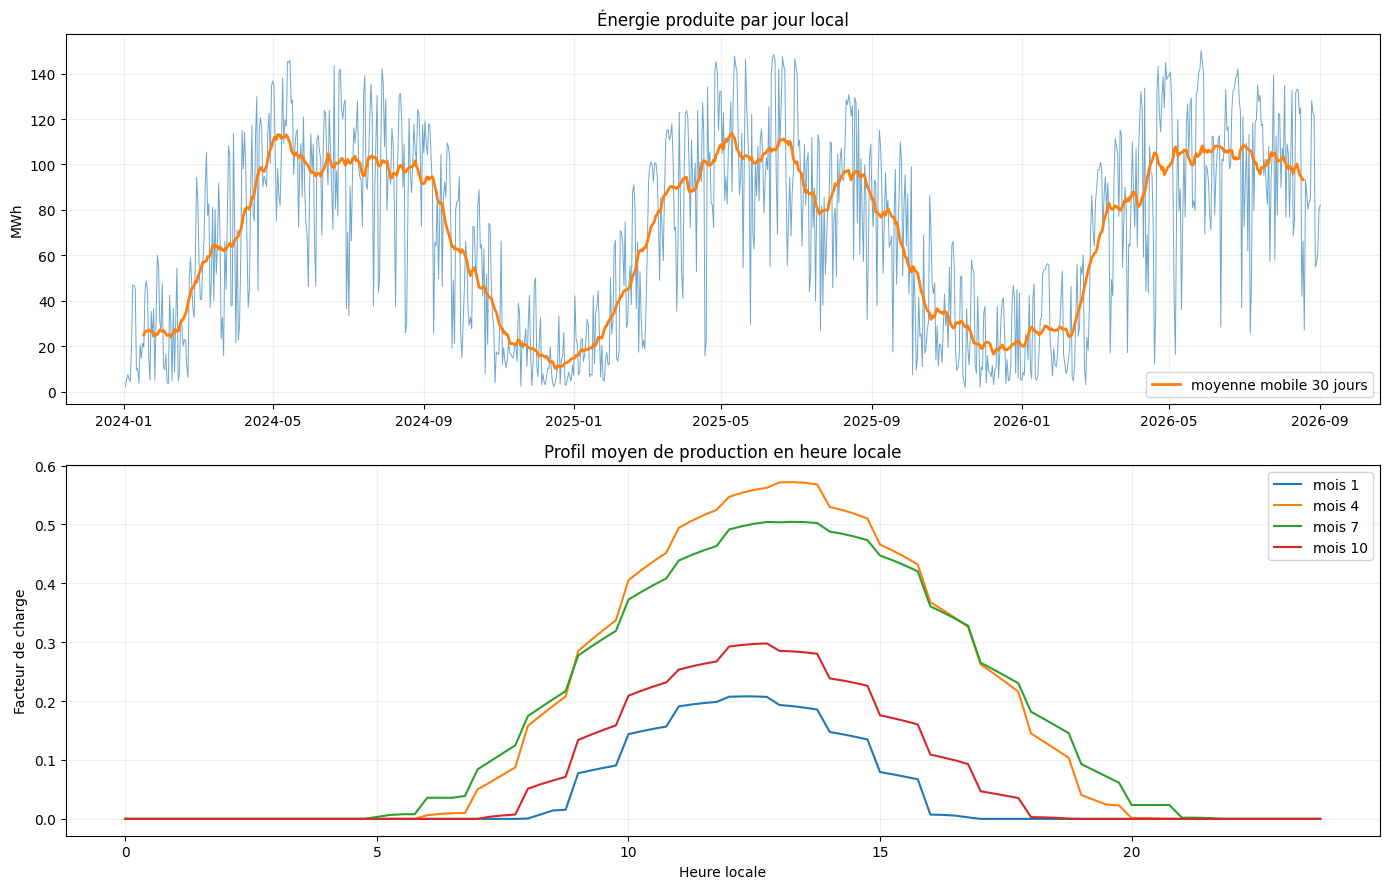

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
axes[0].plot(daily.index, daily['energy_mwh'], linewidth=0.7, alpha=0.65)
axes[0].plot(daily.index, daily['energy_mwh'].rolling(30, center=True).mean(), linewidth=2, label='moyenne mobile 30 jours')
axes[0].set(title='Énergie produite par jour local', ylabel='MWh')
axes[0].legend()
axes[0].grid(alpha=0.2)

profile_frame = local_data.copy()
profile_frame['month'] = profile_frame['timestamp_local'].dt.month
profile_frame['hour_decimal'] = profile_frame['timestamp_local'].dt.hour + profile_frame['timestamp_local'].dt.minute / 60
for month in [1, 4, 7, 10]:
    profile = profile_frame[profile_frame['month'] == month].groupby('hour_decimal')['capacity_factor'].mean()
    axes[1].plot(profile.index, profile.values, label=f'mois {month}')
axes[1].set(title='Profil moyen de production en heure locale', xlabel='Heure locale', ylabel='Facteur de charge')
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.tight_layout()

In [9]:
# Saisons météorologiques définies par mois civil en heure locale Berlin.
# Les blocs sont des repères de lecture ; les heures nocturnes restent visibles.
profile_frame['season'] = pd.cut(
    profile_frame['month'], [0, 2, 5, 8, 11, 12],
    labels=['hiver', 'printemps', 'été', 'automne', 'hiver'], include_lowest=True, ordered=False,
)
profile_frame['hour_block'] = pd.cut(
    profile_frame['hour_decimal'], [-0.01, 6, 10, 14, 18, 24],
    labels=['nuit', 'matin', 'midi', 'soir', 'nuit'], include_lowest=True, ordered=False,
)
hour_block_profile = profile_frame.groupby(['season', 'hour_block'], observed=True)['capacity_factor'].mean().unstack()
hour_block_profile

hour_block,matin,midi,nuit,soir
season,,,,
automne,0.082314,0.306912,0.001343,0.157300
hiver,0.041661,0.193435,0.000000,0.055982
printemps,0.187570,0.513616,0.009196,0.317757
été,0.187934,0.499701,0.018376,0.371372


L'énergie moyenne progresse de 15,8 MWh par jour en décembre à environ 105 MWh en mai et juin. Le profil horaire montre aussi que la production se concentre davantage autour de midi au printemps et en été.

---
## Relier la météo à la production

Je calcule les corrélations pendant les heures éclairées. La nuit, le zéro de production masquerait les relations entre météo et production.

In [10]:
model_variables = cfg['historical_reanalysis']['feature_variables']
daylight_frame = historical_data.loc[daylight, [*model_variables, 'production_mw']].copy()
linear_variables = [variable for variable in model_variables if variable != 'wind_direction_10m']
correlations = pd.DataFrame({
    'pearson_daylight': daylight_frame[linear_variables].corrwith(daylight_frame['production_mw'], method='pearson'),
    'spearman_daylight': daylight_frame[linear_variables].corrwith(daylight_frame['production_mw'], method='spearman'),
}).sort_values('spearman_daylight', key=lambda values: values.abs(), ascending=False)
correlations

,pearson_daylight,spearman_daylight
shortwave_radiation,0.966440,0.971377
direct_radiation,0.939031,0.935956
direct_normal_irradiance,0.856322,0.837098
diffuse_radiation,0.613702,0.782174
relative_humidity_2m,-0.581980,-0.573656
cloud_cover,-0.372663,-0.386999
temperature_2m,0.369677,0.358451
precipitation,-0.137841,-0.174889
wind_speed_10m,-0.028706,-0.012443


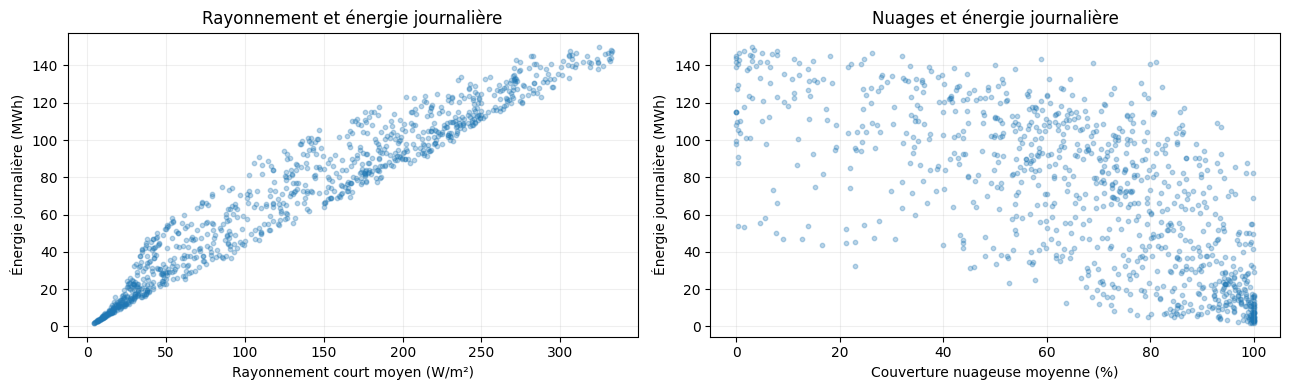

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(daily['mean_shortwave_wm2'], daily['energy_mwh'], s=10, alpha=0.3)
axes[0].set(xlabel='Rayonnement court moyen (W/m²)', ylabel='Énergie journalière (MWh)', title='Rayonnement et énergie journalière')
axes[1].scatter(daily['mean_cloud_cover_pct'], daily['energy_mwh'], s=10, alpha=0.3)
axes[1].set(xlabel='Couverture nuageuse moyenne (%)', ylabel='Énergie journalière (MWh)', title='Nuages et énergie journalière')
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()

Le rayonnement global est le signal le plus lié à la production pendant les heures éclairées : la corrélation de Spearman vaut 0,97. La relation avec l'humidité est négative (-0,57), tandis que le vent à 10 m apporte presque aucune information directe (-0,01). Ces corrélations décrivent l'ERA5 et la courbe virtuelle ; elles ne mesurent pas une causalité de site.

In [12]:
radiation = historical_data[radiation_columns].copy()
balance_error = radiation['shortwave_radiation'] - radiation['direct_radiation'] - radiation['diffuse_radiation']
max_balance_index = balance_error.abs().idxmax()
radiation_diagnostics = pd.DataFrame([{
    'mean_absolute_balance_error': balance_error.abs().mean(),
    'p99_absolute_balance_error': balance_error.abs().quantile(0.99),
    'max_absolute_balance_error': balance_error.abs().max(),
    'rows_with_error_above_1': int(balance_error.abs().gt(1).sum()),
    'max_error_timestamp_utc': historical_data.loc[max_balance_index, 'timestamp'],
}])
display(radiation.corr())
display(radiation_diagnostics.T.rename(columns={0: 'value'}))

,shortwave_radiation,direct_radiation,diffuse_radiation,direct_normal_irradiance
shortwave_radiation,1.000000,0.959251,0.816244,0.892495
direct_radiation,0.959251,1.000000,0.619748,0.926069
diffuse_radiation,0.816244,0.619748,1.000000,0.585490
direct_normal_irradiance,0.892495,0.926069,0.585490,1.000000


,value
mean_absolute_balance_error,0.0
p99_absolute_balance_error,0.0
max_absolute_balance_error,0.0
rows_with_error_above_1,0
max_error_timestamp_utc,2024-01-01 00:00:00+00:00



---
## Suite de l'étude

La prochaine étape construira les variables de calendrier, de position solaire, de rayonnement, rollings et les lags de production disponibles au cutoff J-1.

## Points à retenir

L'historique couvre le 1er janvier 2024 au 1er septembre 2026, sans trou à 15 minutes. Les jours incomplets aux bords du fichier ne sont pas intégrés aux statistiques journalières.

La production virtuelle moyenne est de 2,90 MW, soit un facteur de charge de 13,1 %. L'énergie quotidienne moyenne est faible en hiver et atteint environ 105 MWh en mai et juin.

Le rayonnement global est le signal le plus associé à la production pendant les heures éclairées. Le direct et le diffus seront conservés pour l'entraînement, puis leur apport sera évalué avec le modèle.